<a href="https://colab.research.google.com/github/kanebako-s/olist-data-analysis/blob/main/Kaggle_Olist_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## おまじない。

In [ ]:
# --- ライブラリのインポート ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# --- グラフの見た目を整える ---
sns.set(style="whitegrid") # グラフにグリッド（網掛け）を出して見やすくする
plt.rcParams["figure.figsize"] = (10, 6) # グラフの基本サイズを少し大きくする

# --- データの表示設定 ---
pd.options.display.max_columns = None # 列数が多い時、省略（...）せずに全部表示する
pd.set_option('display.float_format', '{:.2f}'.format) # 小数点以下を2桁に固定して見やすくする

# --- 日本語化（重要！） ---
!pip install japanize-matplotlib
import japanize_matplotlib # これでグラフの日本語が「□」にならずに済む

# --- Worldcloudのインストール ---
!pip install wordcloud
from wordcloud import WordCloud

## ファイルの読み込み。

In [ ]:
FILE_PATH = '/content/drive/MyDrive/Olist_Dateanalist_Learning' # ファイルの読み込みが自分専用になっている。あとで直しやすいようにしている。

customers_dataset = pd.read_csv(FILE_PATH + '/olist_customers_dataset.csv')
orders_dataset = pd.read_csv(FILE_PATH + '/olist_orders_dataset.csv')
order_reviews_dataset = pd.read_csv(FILE_PATH + '/olist_order_reviews_dataset.csv')



## それぞれのテーブルの中身を確認する。

In [ ]:
# customers_dataset.head(0) # 注文番号と顧客の固有識別番号、顧客の州と街。


顧客データ（customers_dataset）の構造把握。
* ** 顧客の固有識別子の重複についての注意 ** customer_unique_idのデータが重複していたとしても、一回の注文で複数のものを頼んだ可能性もありECサイトを別日程で再利用したかどうかは本テーブルのみでは判別不能。

** 分析方針 **

真のリピート率は"orders_dataset"と結合後、"customer_unique_id"をキーとして"order_id"の数をカウントする。

"order_id"の数が１であれば「新規顧客」、

"order_id"の数が２以上であれば「リピーター」と定義する。

リピーターの1回目の注文の満足度スコアが高いことは想像がつきます。

新規顧客について、1回目の注文の満足度スコアが高いのに再利用してない人は注文物の品質は満足したが配送関係で信頼を損なった可能性がある。1回目の満足度スコアが高く配送時間のズレが大きい人は離脱しているかを確認する。

In [ ]:
orders_dataset.head(3) # order_idを主キーとする注文履歴。注文申請時間から配達完了時間までの５種類のタイムスタンプ。
# タイムスタンプのデータ型を確認、修正。推定配達日と実際配達日のズレの計算で使いそうだから。

data_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for time_col in data_cols:
  orders_dataset[time_col] = pd.to_datetime(orders_dataset[time_col])

orders_dataset.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


注文データ（orders_dataset）の構造確認と仮説の構築。

* ** 推定配達日と実際配達日にズレについて ** 推定配達日より二週間早くと届く場合もあれば、二週間遅く届く日もあることが確認できた。この推定配達日のズレは信頼性を損ない顧客満足度に影響すると予想できる。
* ** 配達時間について ** 配達時間は地域性に依存するものの、同じ地域内でも配達時間にばらつきがあり、それが顧客満足度に影響している可能性がある。

** 分析方針 **

* 推定配達日と実際配達日のズレの日数を算出し、満足度スコアとの相関を可視化し確認する。
* 「地域」ごとの配達時間の分散を算出し満足度スコアの低くなる特定の地域を探る。


In [ ]:
order_reviews_dataset.head(20) # レビューの固有識別子、満足度スコア、コメント、レビュー作成時間、レビューに対する運営の回答時間。

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


レビューデータ（order_reviews_dataset）の構造確認と評価指標の選定。

** レビューデータ確認による洞察 **
* ** 運営の対応速度について ** レビューが投稿されてから運営が回答するまでの時間はこの２０件の中では最大７日だった。このデータはリピート率に影響していなさそう。
* ** コメントをする人の割合について **コメントタイトルとコメントは書いている人の割合が少ない。一部のユーザーの意見で全体の傾向は測れないため指標として不適。

** 分析方針 **

レビューデータでは、満足度スコアのみを主要な指標にすることでリピート率の向上に役立てる。満足度スコア１がリピート率に与える影響を確認する。

In [ ]:
# ３つのテーブルを一つにまとめる。
df_temp = pd.merge(orders_dataset, customers_dataset, on='customer_id')
df_final = pd.merge(df_temp, order_reviews_dataset, on='order_id')

## 分析と可視化

In [ ]:
# 満足度スコア１がリピート率に与える影響を確認する。
# スコア1の注文だけを抽出
score_1_orders = df_final[df_final['review_score'] == 1].copy()

# 顧客ごとに、最も古い（最初の）スコア1の日付を取得
first_score_1_date = score_1_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_score_1_date.columns = ['customer_unique_id', 'first_score_1_at']

# 元のデータに「最初のスコア1の日付」を結合
df_final = pd.merge(df_final, first_score_1_date, on='customer_unique_id', how='left')

# スコア1を付けた日よりも後の日付の注文があれば True
df_final['is_order_after_score_1'] = df_final['order_purchase_timestamp'] > df_final['first_score_1_at']

# スコア1経験済みリピート者/スコア1経験済みの全顧客が知りたい。
# スコア1を経験した人だけに絞る
affected_customers = df_final[df_final['first_score_1_at'].notnull()]

# 顧客ごとに、一度でも「スコア1後の注文」があるかを確認
churn_analysis = affected_customers.groupby('customer_unique_id')['is_order_after_score_1'].any().value_counts()

# ユニーク顧客の全体の人数。
unique_cutomer_count = df_final['customer_unique_id'].nunique()
print('顧客全体の人数:')
print(unique_cutomer_count)

print('----------------------')

print("スコア1を付けた後のリピート状況:")
print(churn_analysis)

顧客全体の人数:
95380
----------------------
スコア1を付けた後のリピート状況:
is_order_after_score_1
False    10863
True       330
Name: count, dtype: int64


満足度スコア1がリピート率に与える影響について。

** 分析結果 **

* 満足度スコア1を付けたことのある顧客は、その97%がその後二度と注文していない事が確認できた。
* これにより満足度スコア1は単なる不満ではなく、明確な離脱要因となっている事がわかる。
* 満足度スコア1を付けたことのある顧客は全体の11%である事がわかった。

** 分析方針 **

満足度スコア1と評価した原因を特定し、その改善ができればリピート率向上に繋がる。

「配送遅延」「商品不備」「価格相応でない」などからスコア1の不満の主因となっているものを特定する。

全体の11%のほぼ全ての97%の顧客が本来もたらしたであろうLTV（顧客生涯価値）を算出し、改善による経済的インパクトを可視化する。

In [27]:
df_final.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,first_score_1_at,is_order_after_score_1
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaT,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,NaT,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,NaT,False


In [30]:
# 支払いデータセットの読み込みと結合。
order_payments_dataset = pd.read_csv(FILE_PATH + "/olist_order_payments_dataset.csv")

# データセットの結合。
df_final = pd.merge(df_final, order_payments_dataset, on='order_id')

# 平均注文単価 (AOV: Average Order Value) の算出
# priceが含まれるテーブルを結合していると想定
avg_order_value = df_final['payment_value'].mean()
print('平均注文単価')
print(avg_order_value)

# 全体平均のリピート回数を算出
# (全注文数 / 全ユニーク顧客数)
total_orders = df_final['order_id'].nunique()
total_customers = df_final['customer_unique_id'].nunique()
avg_purchase_frequency = total_orders / total_customers
print('全体平均のリピート回数')
print(avg_purchase_frequency)
# 顧客1人あたりの「期待LTV」を簡易算出
expected_ltv = avg_order_value * avg_purchase_frequency
print('期待LTV')
print(expected_ltv)

平均注文単価
153.6662365809196
全体平均のリピート回数
1.0345254196416402
期待LTV
158.9716278836274


離脱した97%の顧客が本来もたらしたであろうLTV（顧客生涯価値）を算出する。

** 分析結果 **

* スコア1を付けた顧客だけでなく、顧客全体の平均リピート回数が1.03回と極めて低い事がわかった。単純に計算するならサービス全体で顧客の離脱率が97%に近似することから、スコア1の改善だけではビジネス上のインパクトが限定的である可能性が示唆された。
* したがってスコア1の顧客がなぜスコア1にしたかを考えるのではなく、サービス全体として継続利用したくないと感じる原因があることが浮き彫りになった。

** 分析方針 **

「満足度スコアが1であること」の改善がリピート率に直結しない事から、満足度スコアは飾りでリピート率に直結にない可能性が高い。

これからは顧客が継続利用しない原因を探る。顧客の不満の傾向を掴むため、レビュー文の単語の出現頻度を可視化してテキストマイニングで原因を候補を抽出する。

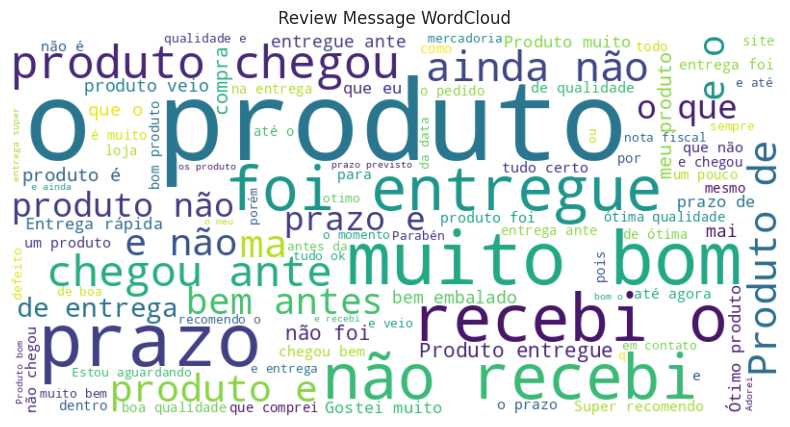

In [31]:
# レビューがあるデータだけを抽出。
reviews = df_final['review_comment_message'].dropna()

# 全てのレビューを一つのテキストに結合
all_reviews_text = " ".join(reviews)

# WordCloudの設定（ポルトガル語のストップワード等を考慮した簡易版）
# ※本来はポルトガル語特有の処理が必要ですが、まずはこれで「形」にします
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_reviews_text)

# 表示
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Review Message WordCloud')
plt.show()

テキストマイニングによる離脱原因の抽出。

注釈：
本分析では迅速に不満の傾向を把握することを優先し、ストップワードの厳密な除去は行っていません。しかし、表示された主要な単語から顧客が何に注目しているかの片鱗を探りました。

** 分析結果 **

* produto（製品）、muito bom（良い）、prazo（期限 / 納期）、recebi（受け取った）、entregue（配達された）、chegou（届いた）が目に付くことから不満の原因は、製品品質と配達予定日と実際配達日のズレにある可能性がある。


In [32]:
# 予定配達日ー実際配達日＝配達日のズレ　（＋なら早く届いたと言う事。ーなら遅延したと言う事。０が一番良い。）
df_final['delivery_diff'] = (df_final['order_estimated_delivery_date'] - df_final['order_delivered_customer_date']).dt.days

df_final[['delivery_diff', 'review_score', 'customer_unique_id','order_estimated_delivery_date', 'order_delivered_customer_date']].head(20)

df_final['delivery_diff'].describe() # 予定より早く配達されることが多いことが明確になった。半年遅れや半年早く届くこともあるらしい。

,delivery_diff
count,100647.00
mean,10.94
std,10.12
min,-189.00
25%,6.00
50%,11.00
75%,16.00
max,146.00


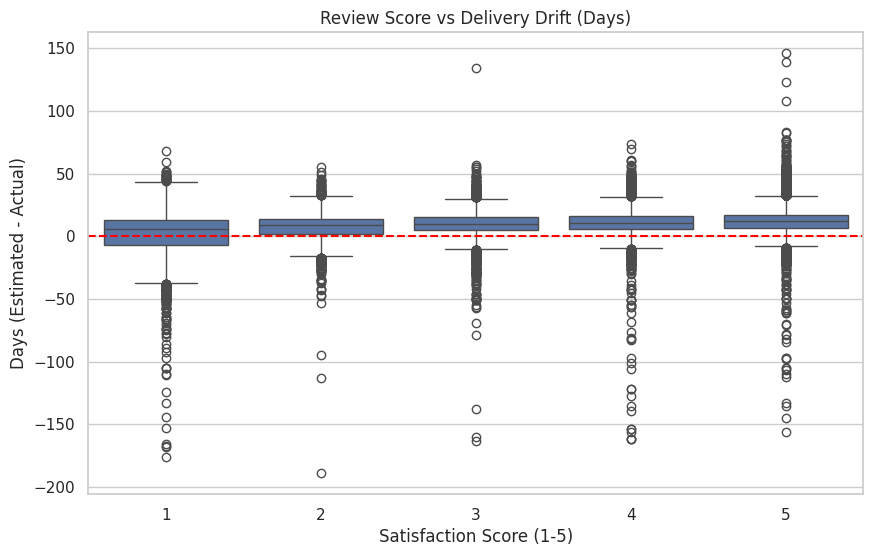

In [33]:
# 配送のズレと満足度スコアの関係を可視化。
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_diff', data=df_final)
plt.title('Review Score vs Delivery Drift (Days)')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Days (Estimated - Actual)')
plt.axhline(0, color='red', linestyle='--') # 0日の線（予定通り）
plt.show()

可視化による満足度スコアと配送のズレの大きさの関係性の確認。


** 分析結果 **

* 配達が遅延していても満足度が５になることある。
* スコア１のグループは早すぎる配達と遅すぎる配達の割合が他グループと比較して顕著に大きいことから、顧客は配達予定日にある程度の正確性を求めている事がわかる。
* 配達予定日と実際配達日のズレが小さいものでも満足度スコア全体にデータが分散している。配送が完璧であっても不満が生じる「配送以外の不満」が存在する事がわかる。

** 結論と次の仮説 **

大きく配達日のズレた注文以外は不満の原因が「配達」ではなく「商品品質」にある可能性が高い。

特定の地域の配送業者が商品を手荒に扱っていると仮説を立てて、次は地域ごとの満足度スコア分布を確認する。

In [35]:
# 地域（customer_state）ごとに、スコアとズレの平均・標準偏差（ばらつき）を計算
state_analysis = df_final.groupby('customer_state').agg({
    'review_score': 'mean',
    'delivery_diff': ['mean', 'std'], # 平均と標準偏差（ばらつき）
    'order_id': 'count'               # 注文数（データが少なすぎる地域を除外するため）
}).reset_index()

# カラムの名前を分かりやすくする。
state_analysis.columns = ['state', 'score_mean', 'diff_mean', 'diff_std', 'order_count']

# 注文件数の極端に少ない地域はノイズになるので除外し、スコアが低い地域順に並べ替える。
worst_state = state_analysis[state_analysis['order_count'] > 100].sort_values(by='score_mean')

# 各州ごとに、スコア1が占める割合（％）を計算する
state_bad_rate = df_final.groupby('customer_state').apply(
    lambda x: (x['review_score'] == 1).sum() / len(x) * 100
).reset_index(name='score_1_rate')

# worst_stateとstate_bad_rateを結合して、割合が高い順に並べる
worst_rate_state = worst_state.merge(state_bad_rate, left_on='state', right_on='customer_state')
worst_rate_state[worst_rate_state['order_count'] > 100].sort_values(by='score_1_rate', ascending=False).head(10)


worst_rate_state.reset_index().head(23)

/tmp/ipykernel_3171/650856113.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_bad_rate = df_final.groupby('customer_state').apply(


,index,state,score_mean,diff_mean,diff_std,order_count,customer_state,score_1_rate
0,0,MA,3.73,8.69,13.99,766,MA,18.54
1,1,AL,3.75,7.61,13.26,428,AL,17.52
2,2,SE,3.79,9.11,17.61,360,SE,18.33
3,3,PA,3.85,13.20,13.78,1003,PA,16.05
4,4,CE,3.86,9.99,14.35,1391,CE,15.53
5,5,BA,3.87,9.93,12.57,3586,BA,14.81
6,6,PI,3.87,10.26,15.96,519,PI,15.61
7,7,RJ,3.88,10.85,13.42,13444,RJ,17.00
8,8,MT,4.01,13.47,9.94,954,MT,12.68
9,9,PE,4.01,12.44,11.89,1720,PE,13.37


特定の地域の配送業者の配達品質が低いのでは、と言う予想についての確認。

** 分析結果 **

* 満足度スコア平均の小さい州はdiff_std（ズレの標準偏差）が大きい傾向があることから「いつ届くか予想のつかない配達状況」に不満を持っている事がわかる。
* 各地域で配達予定日より平均１０日程度早く配達されていること分かる。このことから予定配達日の設定は当てにならないものであり、顧客の信頼性を損なう一因になっているものと予想される。
* 注文数が圧倒的に多いSP（約4.3万件）は、スコア平均が 4.17 と高く、スコア1の割合も 9.7% と1割を切っている。
* つまり都市部では満足度が比較的良い一方で、地方部では配達予定日通りに届かない事が常態化されている。

** 改善案 **

地方部の物流網の見直しをする。
地方部の顧客には予定配達日より大きく前後することを事前に徹底する。

** 分析方針 **
配達予定日のズレについては十分分析できた。

## ファイルの読み込み ２


In [ ]:
order_items_dataset = pd.read_csv(FILE_PATH + '/olist_order_items_dataset.csv')
products_dataset = pd.read_csv(FILE_PATH + '/olist_products_dataset.csv')
product_name_translation = pd.read_csv(FILE_PATH + '/product_category_name_translation.csv')